# Coding Practice \#4: Due November 21 at midnight in Canvas

All files needed are located in the 'cp4_data_f25.zip' file.

Answer the questions below in a Jupyter notebook. You can modify this notebook by adding cells with your answers.

In [2]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols

# os.chdir('Users/jackson/Documents/ECON570') #Mac 
os.chdir('C:/Users/messy/Desktop/School/ECON570') #PC

## Exercise 0: Kaiman, Jackson
Replace 'Last, First' above with your actual name. Enter it as your last name, first name.

## Exercise 1: Event study

The data 'cp4_event.csv' contains simulated panel data with an observation for an individual's outcome in each year. Some individuals are treated, some are not. For treated individuals, their treatment year is indicated. *Hint:* The file is structured similarly to the file 'sw06.csv' used in class.

1. Read in the data. What is the minimum treatment year? What is the maximum treatment year? How many individuals are in the data? How many individuals are treated?

In [3]:
event = pd.read_csv('data/cp4_event.csv')
event.head()

,id,year,treated,treat_year,outcome
0,1,1,0,NaN,1.045215
1,1,2,0,NaN,-0.393152
2,1,3,0,NaN,-0.963596
3,1,4,0,NaN,0.741949
4,1,5,0,NaN,-1.231438


2. Plot a histogram of the year of treatment. Describe the results.

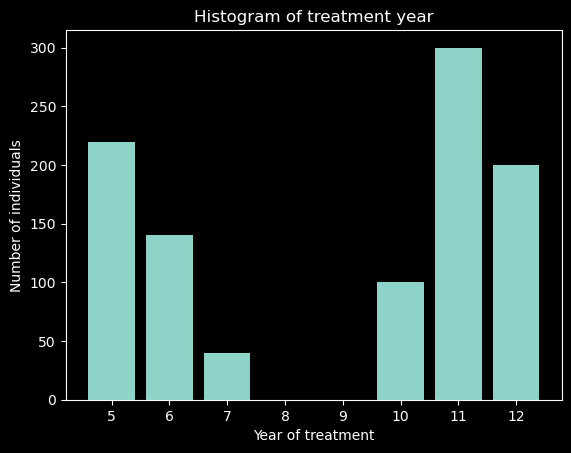

In [4]:
treated_years = (
    event.loc[event["treated"] == 1, "treat_year"]
      .dropna()
      .astype(int)
)
plt.hist(
    treated_years,
    bins=range(treated_years.min(), treated_years.max() + 2),  # one bin per year
    align="left",
    rwidth=0.8
)
plt.xlabel("Year of treatment")
plt.ylabel("Number of individuals")
plt.title("Histogram of treatment year")
plt.show()


Treatment clearly does not occur at a single point in time, instead, it seems to be stagghered across multiple years. This is expected.
From the Histogram:
 - Treeatment begins around year 5
 - The early treatment cohorts are leage: roughly 200+ individuals treated in year 5 and ~140 in year 6. 
 - Year 7 is much smaller, with only about 40
 - no treatment in years 8-9
 - Treatment picks up again in year 10, with about 100 individuals.
 - largest cohort in year 11, with around 300. 
 - Finally, about 200 treated in year 12.

3. Suppose that the goal is to estimate an event study on a *balanced panel* where each treated individual is observed for the same number of pre-treatment periods and post-treatment periods. If this is the case, how many pre-treatment periods can we include in our regression? How many post-treatment periods?

In [5]:
y_min = event["year"].min()
y_max = event["year"].max()

treated_df = event[event["treated"] == 1].copy()
t_min = treated_df["treat_year"].min()
t_max = treated_df["treat_year"].max()

L_pre  = t_min - y_min
L_post = y_max - t_max

L_pre, L_post

(4.0, 8.0)

4. Plot a line plot with three series of average outcomes vs. year: one for the control individuals, one for individuals treated in year 5, and one for individuals treated in year 10. Put vertical lines at the year of treatment for each treated group. Use different colors and/or line styles to distinguish the series. Apply principles of graphical excellence.

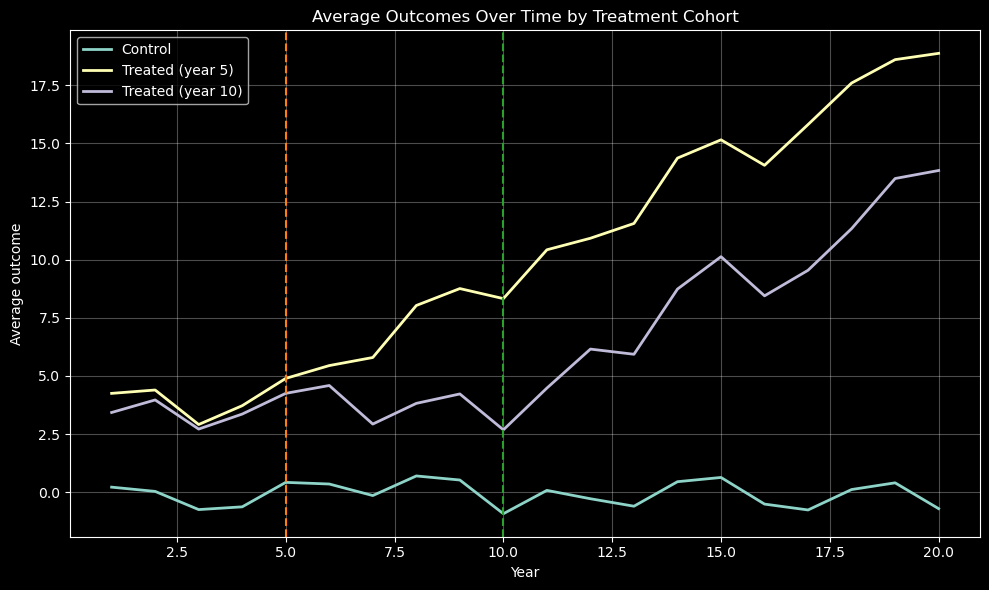

In [6]:
control = event[event["treated"] == 0]

treated_5 = event[event["treat_year"] == 5]
treated_10 = event[event["treat_year"] == 10]


avg_control = control.groupby("year")["outcome"].mean()
avg_5 = treated_5.groupby("year")["outcome"].mean()
avg_10 = treated_10.groupby("year")["outcome"].mean()

plt.figure(figsize=(10,6))

plt.plot(avg_control.index, avg_control.values,
         label="Control", linewidth=2)

plt.plot(avg_5.index, avg_5.values,
         label="Treated (year 5)", linewidth=2)

plt.plot(avg_10.index, avg_10.values,
         label="Treated (year 10)", linewidth=2)

plt.axvline(5, color="tab:orange", linestyle="--", linewidth=1.5)
plt.axvline(10, color="tab:green", linestyle="--", linewidth=1.5)

plt.xlabel("Year")
plt.ylabel("Average outcome")
plt.title("Average Outcomes Over Time by Treatment Cohort")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

5. Limit the relative years to those between -5 and +5 (including the endpoints) for the treated individuals. Generate relative time-to-treatment indicators.

In [7]:
event["rel_year"] = event["year"] - event["treat_year"]

event = event.loc[
    (event["treated"] == 0) |
    ((event["rel_year"] >= -5) & (event["rel_year"] <= 5))
].copy()

for i in range(-5, 6):
    colname = f"rel_{i}"
    event[colname] = (event["rel_year"] == i).astype(int)

event.head()    

,id,year,treated,treat_year,outcome,rel_year,rel_-5,rel_-4,rel_-3,rel_-2,rel_-1,rel_0,rel_1,rel_2,rel_3,rel_4,rel_5
0,1,1,0,NaN,1.045215,NaN,0,0,0,0,0,0,0,0,0,0,0
1,1,2,0,NaN,-0.393152,NaN,0,0,0,0,0,0,0,0,0,0,0
2,1,3,0,NaN,-0.963596,NaN,0,0,0,0,0,0,0,0,0,0,0
3,1,4,0,NaN,0.741949,NaN,0,0,0,0,0,0,0,0,0,0,0
4,1,5,0,NaN,-1.231438,NaN,0,0,0,0,0,0,0,0,0,0,0


6. Build the formula for the event study and fit it using `statsmodels`. Make sure your regression includes the never-treated individuals. Create a DataFrame that contains the point estimates and upper and lower bounds of the 95% confidence interval.

In [10]:
import statsmodels.formula.api as smf
import pandas as pd

ks = [k for k in range(-5, 6) if k != -1]

rel_terms = [f"rel_{k}" for k in ks]

rel_terms_formula = [f"Q('rel_{k}')" for k in ks]

# build formula
formula = "outcome ~ " + " + ".join(rel_terms_formula) + " + C(id) + C(year)"
print(formula)

event_mod = smf.ols(formula, data=event).fit()

coef = event_mod.params[rel_terms_formula]
conf = event_mod.conf_int().loc[rel_terms_formula]

event_es = pd.DataFrame({
    "rel_time": ks,                    # -5, -4, ..., 0, ..., 5 (excluding -1)
    "beta": coef.values,
    "ci_lower": conf[0].values,
    "ci_upper": conf[1].values
}).sort_values("rel_time").reset_index(drop=True)

event_es



outcome ~ Q('rel_-5') + Q('rel_-4') + Q('rel_-3') + Q('rel_-2') + Q('rel_0') + Q('rel_1') + Q('rel_2') + Q('rel_3') + Q('rel_4') + Q('rel_5') + C(id) + C(year)


,rel_time,beta,ci_lower,ci_upper
0,-5,-0.254359,-0.721794,0.213076
1,-4,-0.230472,-0.668191,0.207248
2,-3,-0.413676,-0.846849,0.019498
3,-2,-0.419342,-0.838946,0.000261
4,0,-0.208914,-0.628797,0.210970
5,1,0.590675,0.156415,1.024936
6,2,1.796726,1.358300,2.235152
7,3,3.014486,2.579039,3.449934
8,4,4.007209,3.577918,4.436499
9,5,4.779628,4.352307,5.206950


7. Plot the estimates and 95% confidence interval for the event study. Use the "fill between" option to color in the confidence intervals. Describe the results implied by the figure. Does the figure look how you would expect, given the figure we created in step 4? Discuss.

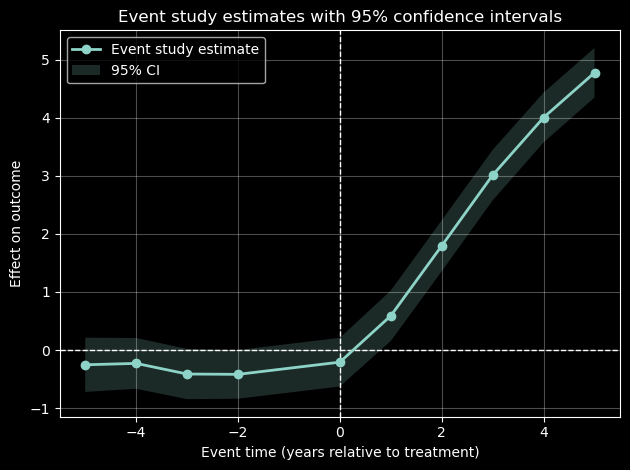

In [11]:
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.plot(
    event_es["rel_time"],
    event_es["beta"],
    marker="o",
    linewidth=2,
    label="Event study estimate"
)

plt.fill_between(
    event_es["rel_time"],
    event_es["ci_lower"],
    event_es["ci_upper"],
    alpha=0.2,
    label="95% CI"
)

plt.xlabel("Event time (years relative to treatment)")
plt.ylabel("Effect on outcome")
plt.title("Event study estimates with 95% confidence intervals")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


8. Estimate a difference-in-differences model comparing the post-period \[0,5\] to the pre-period \[-5,-1\]. Interpret the result.

In [ ]:
event["post"] = ((event["rel_year"] >= 0) & (event["rel_year"] <= 5)).astype(int)

did_mod = smf.ols(
    "outcome ~ treated * post + C(id) + C(year)",
    data=event
).fit()

print(did_mod.summary().tables[1])

delta = did_mod.params["treated:post"]
ci = did_mod.conf_int().loc["treated:post"]
print("DiD estimate:", delta)
print("95% CI:", ci[0], ci[1])


                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.2439      0.325      0.751      0.453      -0.393       0.881
C(id)[T.2]        0.1411      0.404      0.349      0.727      -0.652       0.934
C(id)[T.3]       -1.0068      0.404     -2.490      0.013      -1.800      -0.214
C(id)[T.4]       -1.0193      0.404     -2.521      0.012      -1.812      -0.226
C(id)[T.5]       -0.7833      0.404     -1.937      0.053      -1.576       0.010
C(id)[T.6]        0.9683      0.404      2.395      0.017       0.175       1.761
C(id)[T.7]       -0.0443      0.404     -0.109      0.913      -0.837       0.749
C(id)[T.8]        0.0383      0.404      0.095      0.924      -0.755       0.831
C(id)[T.9]        0.6606      0.404      1.634      0.103      -0.133       1.454
C(id)[T.10]      -0.3189      0.404     -0.789      0.430      -1.112       0.474
C(id)[T.11]     

On average, treatment raises the outcome by about 1.25 units in the five years after treatment compared with the five years before, relative to the change for the never treated group. The confidence interval is tight and far from zero, so the effect is statistically and quantitatively large in this simulated setting.

## Exercise 2: Wine classification

The dataset 'wine.csv' contains information on samples of wine from three different cultivars. The 'cultivar' column takes on three distinct values: 0, 1, and 2. The data also contain several feature variables. The goal is to build a model that predicts the cultivar based on the wine's features.

### Part (a)

1. Read the data into a DataFrame. How many features are there?
2. Create a facet plot using `sns.pairplot()` for all feature columns. Use the `hue=` to distinguish the different cultivars.
3. Well, that is overwhelming... Create new pairplot with only the following features:
  
   'od280/od315_of_diluted_wines', 'proline', 'flavanoids', 'hue'
   
   Again, use `hue=` to distinguish the different cultivars. Do any patterns stand out to you?

### Part (b)

1. Split the data into a 75% testing sample and a 25% training sample. Use `random_state=12`.
2. Fit the training data using a multinomial logistic regression. **Error!**
3. Let's remedy the error by standardizing the feature columns. First run the following import statement:
   
   ```python
    from sklearn import preprocessing
    ```
   
   Next, create a new object by running:
   
   ```python
    scaler = preprocessing.StandardScaler().fit(X_train)
    ```
   
   What type of object is this? Use this new object to `.transform()` both the training and testing feature data.
4. Calculate the `.mean(axis = 0)` and `.std(axis = 0)` of the standardized training feature data. Briefly describe your results.
5. Fit the training data again using a multinomial logistic regression.

### Part (c)

1. Calculate the `.score()` using the testing data.
2. Generate predicted cultivars for the testing data, and use these along with the actual cultivars to generate the confusion matrix. Convert this to a nice looking DataFrame. Describe the results.